In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/sessions_14days.csv')

Mounted at /content/drive


Гипотеза 3: Будни vs Выходные

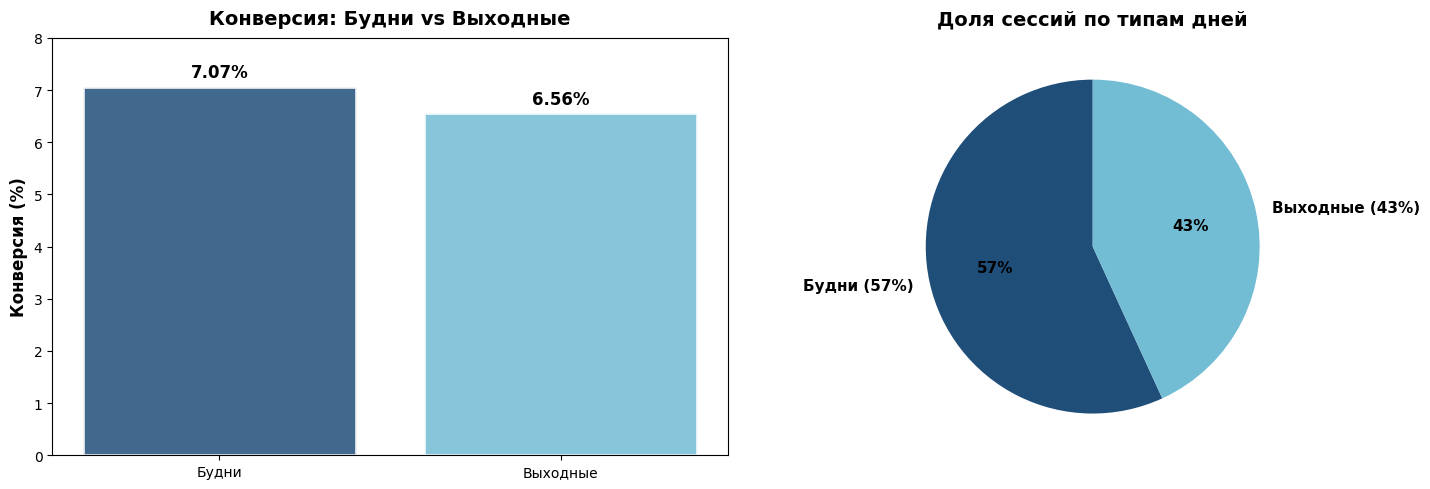

In [16]:
day_conv = df.groupby('is_weekend').agg(
    count=('made_purchase', 'count'),
    purchases=('made_purchase', 'sum'),
    conversion=('made_purchase', 'mean')
).reset_index()

day_conv['conversion'] = day_conv['conversion'] * 100
day_conv['type'] = day_conv['is_weekend'].map({0: 'Будни', 1: 'Выходные'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График Конверсия
colors = ['#1f4e79', '#72bcd4']
bars = axes[0].bar(day_conv['type'], day_conv['conversion'],
                   color=colors, alpha=0.85, edgecolor='white', linewidth=2)

# Подписи на столбцах
for bar, v in zip(bars, day_conv['conversion']):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{v:.2f}%', ha='center', va='bottom',
                fontweight='bold', fontsize=12)

axes[0].set_title('Конверсия: Будни vs Выходные', fontweight='bold', fontsize=14, pad=10)
axes[0].set_ylabel('Конверсия (%)', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 8)

# График Доля сессий
labels = [f'{t} ({c/len(df)*100:.0f}%)' for t, c in zip(day_conv['type'], day_conv['count'])]
axes[1].pie(day_conv['count'], labels=labels, autopct='%1.0f%%',
            colors=colors, startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Доля сессий по типам дней', fontweight='bold', fontsize=14, pad=10)

plt.tight_layout()
plt.savefig('hyp4_clean_blue.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


Z-тест:

две группы с бинарным исходом (покупка/не покупка)

выборки большие (236M + 179M = 415M сессий)

сравниваем пропорции (7.07% vs 6.56%)

выборки независимы

выполняется условие (n * p > 5 и n * (1-p) > 5), работает ЦПТ



In [14]:
from statsmodels.stats.proportion import proportions_ztest

# Количество покупок и сессий
count = day_conv['purchases'].values
nobs = day_conv['count'].values

stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
print(f"\nZ-статистика: {stat:.3f}")
print(f"p-value: {pval:.6f}")

if pval < 0.05:
    print("СТАТИСТИЧЕСКИ ЗНАЧИМО!")
    diff = abs(day_conv['conversion'].diff().iloc[-1])
    print(f"Разница: +{diff:.2f} п.п. (Будни лучше)")
else:
    print("Разница НЕ значима")


Z-статистика: 20.236
p-value: 0.000000
СТАТИСТИЧЕСКИ ЗНАЧИМО!
Разница: +0.51 п.п. (Будни лучше)
